# Part III – NLP Task: Sentiment Analysis
## Text Classification with RNN and LSTM
**Dataset:** Financial Phrase Bank  
**Student:** Your Name | **ID:** WLVXXXX  
**Module:** 6CS012 – Herald College Kathmandu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 0 – Install Libraries

In [ ]:
!pip install nltk wordcloud contractions gensim gradio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00


In [ ]:
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

import contractions
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import gensim.downloader as gensim_api

print('All libraries loaded!')

All libraries loaded!


---
## Task 4.5.1 – Text Preprocessing, Tokenization and Sequence Padding

### Step 1 – Load the Dataset using Pandas

In [ ]:
# Upload financial_phrase.csv to Colab or mount Drive
# from google.colab import drive; drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/financial_phrase.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nClass distribution:')
print(df['label'].value_counts())
df.head()

Shape: (2264, 2)
Columns: ['text', 'label']

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


### Step 2 – Clean the Text

In [ ]:
df = df.dropna().drop_duplicates().reset_index(drop=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,"According to Gran , the company has no plans t...",according gran company plan move production ru...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled eur e...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increased eur operating...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur eur corresponding pe...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur eur representing...,positive


### Step 3 – Visualize the Cleaned Data

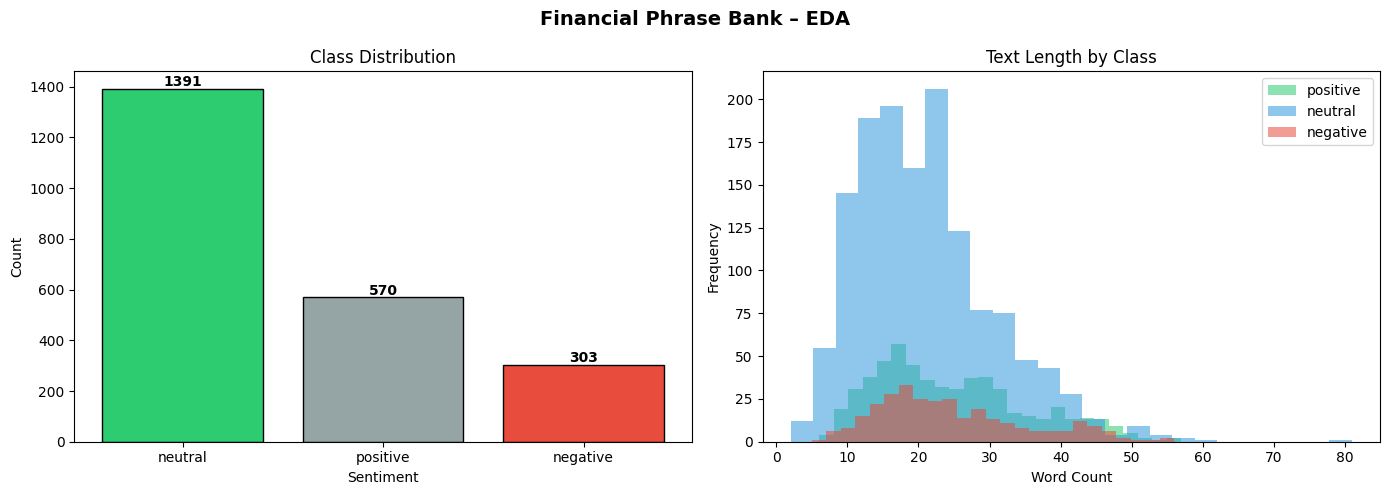

In [ ]:
# Class distribution + text length
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Financial Phrase Bank – EDA', fontsize=14, fontweight='bold')

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#95a5a6','#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

for lbl, col in {'positive':'#2ecc71','neutral':'#3498db','negative':'#e74c3c'}.items():
    axes[1].hist(df[df['label']==lbl]['text_length'], bins=25, alpha=0.55, label=lbl, color=col)
axes[1].set_title('Text Length by Class')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency'); axes[1].legend()

plt.tight_layout(); plt.savefig('eda.png', dpi=120); plt.show()

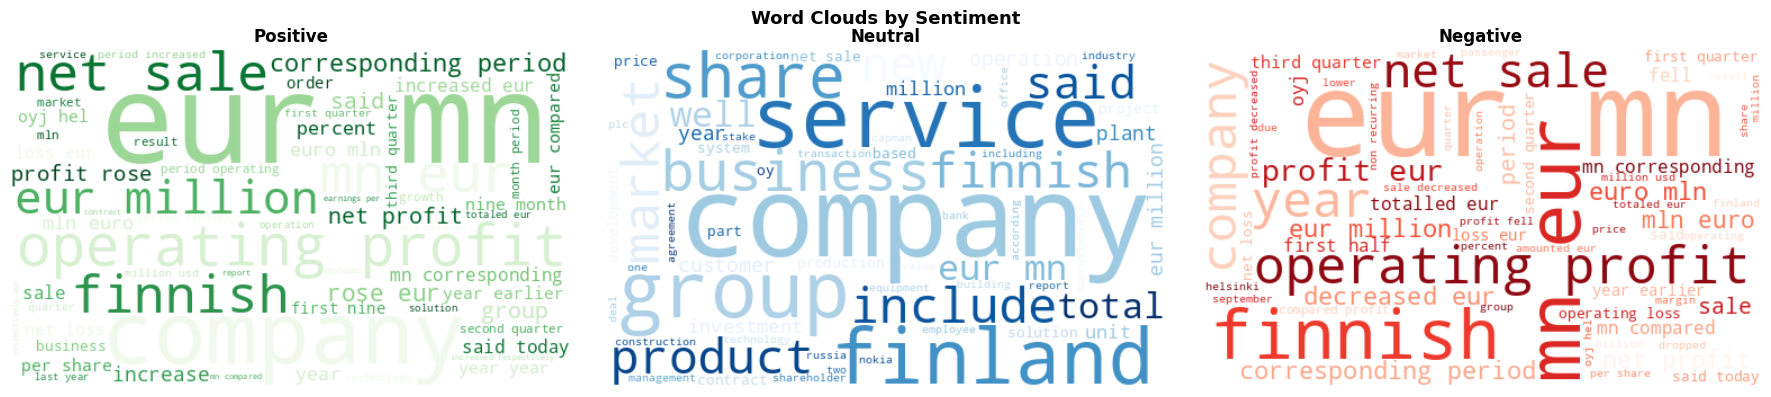

In [ ]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Word Clouds by Sentiment', fontsize=13, fontweight='bold')

for ax, (lbl, cmap) in zip(axes, {'positive':'Greens','neutral':'Blues','negative':'Reds'}.items()):
    blob = ' '.join(df[df['label']==lbl]['clean_text'])
    wc = WordCloud(width=500, height=300, background_color='white', colormap=cmap, max_words=60).generate(blob)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(lbl.capitalize(), fontweight='bold')

plt.tight_layout(); plt.savefig('wordclouds.png', dpi=120); plt.show()

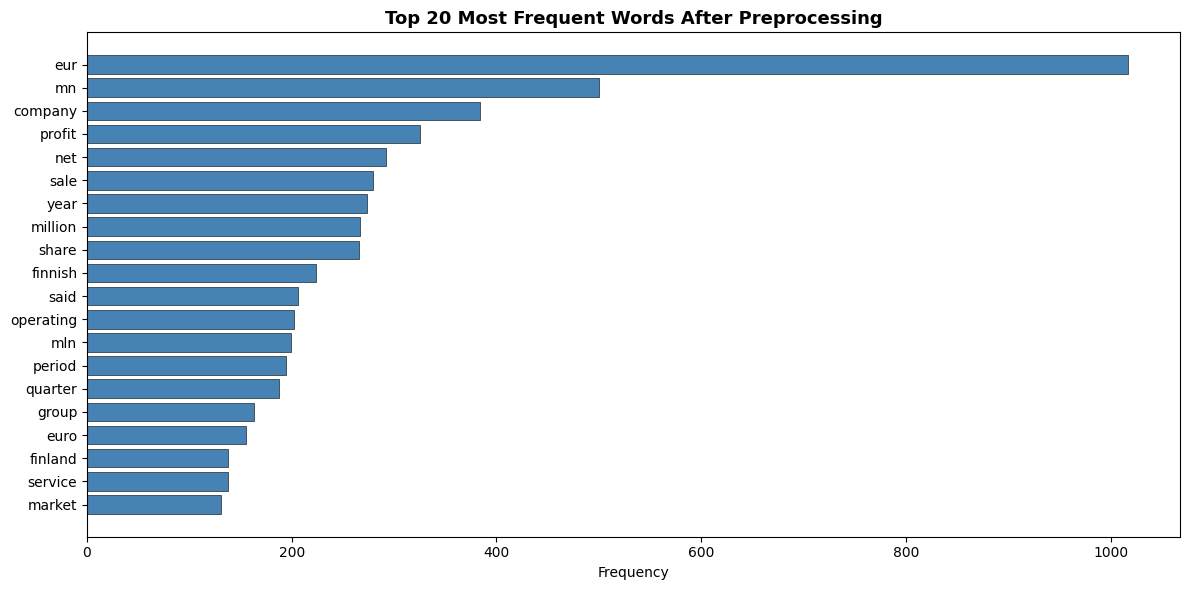

In [ ]:
# Top 20 most frequent words after cleaning
all_words = ' '.join(df['clean_text']).split()
top_20 = Counter(all_words).most_common(20)
words_df = pd.DataFrame(top_20, columns=['word', 'count'])

plt.figure(figsize=(12, 6))
plt.barh(words_df['word'][::-1], words_df['count'][::-1], color='steelblue', edgecolor='black', linewidth=0.4)
plt.title('Top 20 Most Frequent Words After Preprocessing', fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout(); plt.savefig('top20.png', dpi=120); plt.show()

### Step 4 – Tokenization and Padding

In [ ]:
# Label encoding
LABEL_MAP   = {'negative': 0, 'neutral': 1, 'positive': 2}
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']
NUM_CLASSES = 3

df['label_enc'] = df['label'].map(LABEL_MAP)
print('Label encoding done.')
print(df[['label','label_enc']].drop_duplicates().sort_values('label_enc'))

Label encoding done.
        label  label_enc
292  negative          0
0     neutral          1
1    positive          2


In [ ]:
# 80/20 train-test split
X = df['clean_text'].values
y = df['label_enc'].values
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1811 | Test: 453


In [ ]:
# Keras Tokenizer
VOCAB_SIZE = 8000
tokenizer  = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)      # fit on training data only

word_index   = tokenizer.word_index
ACTUAL_VOCAB = min(VOCAB_SIZE, len(word_index) + 1)
print(f'Unique tokens : {len(word_index)}')
print(f'Vocab used    : {ACTUAL_VOCAB}')

Unique tokens : 4251
Vocab used    : 4252


In [ ]:
# Convert to sequences
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding (95th) to avoid excessively long sequences
MAX_LEN = int(np.percentile([len(s) for s in train_seq], 95))
print(f'MAX_LEN (95th percentile): {MAX_LEN}')

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad: {X_train_pad.shape}')
print(f'X_test_pad : {X_test_pad.shape}')

MAX_LEN (95th percentile): 23
X_train_pad: (1811, 23)
X_test_pad : (453, 23)


---
## Task 4.5.2 – Model Building
Three models as required:
- **Model 1:** Simple RNN + Trainable Embedding
- **Model 2:** LSTM + Trainable Embedding
- **Model 3:** LSTM + Pretrained Word2Vec Embedding

### Model 1 – Simple RNN with Trainable Embedding

In [ ]:
EMBED_DIM = 64

model1 = Sequential(name='Model1_SimpleRNN')
model1.add(Embedding(input_dim=ACTUAL_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN))
model1.add(SpatialDropout1D(0.40))
model1.add(SimpleRNN(64, name='simple_rnn'))
model1.add(Dropout(0.50))
model1.add(Dense(32, activation='relu'))
model1.add(Dropout(0.40))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 23, 64)         │       272,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 23, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,563 (1.08 MB)

 Trainable params: 282,563 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 – LSTM with Trainable Embedding

In [ ]:
model2 = Sequential(name='Model2_LSTM')
model2.add(Embedding(input_dim=ACTUAL_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN))
model2.add(SpatialDropout1D(0.40))
model2.add(LSTM(64, return_sequences=True, name='lstm_1'))
model2.add(Dropout(0.50))
model2.add(LSTM(32, name='lstm_2'))
model2.add(Dropout(0.40))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(NUM_CLASSES, activation='softmax'))

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 23, 64)         │       272,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 23, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 23, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,723 (1.22 MB)

 Trainable params: 318,723 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 – LSTM with Pretrained Word2Vec Embeddings
> As specified in the assessment appendix: load pretrained Word2Vec via gensim

In [ ]:
# Load Word2Vec pretrained model (word2vec-google-news-300)
# ~1.6 GB – takes a few minutes on Colab
print('Loading Word2Vec...')
w2v_model = gensim_api.load('word2vec-google-news-300')
print('Word2Vec loaded! Vocab size:', len(w2v_model.key_to_index))

Loading Word2Vec...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded! Vocab size: 3000000


In [ ]:
# Build embedding matrix from Word2Vec
W2V_DIM = 300
found = missed = 0
embedding_matrix = np.zeros((ACTUAL_VOCAB, W2V_DIM))

for word, idx in word_index.items():
    if idx >= ACTUAL_VOCAB:
        continue
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.05, size=(W2V_DIM,))
        missed += 1

print(f'Found: {found} | Not found: {missed} | Coverage: {found/(found+missed)*100:.1f}%')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Found: 3379 | Not found: 872 | Coverage: 79.5%
Embedding matrix shape: (4252, 300)


In [ ]:
model3 = Sequential(name='Model3_LSTM_Word2Vec')
model3.add(Embedding(input_dim=ACTUAL_VOCAB,
                     output_dim=W2V_DIM,
                     weights=[embedding_matrix],
                     input_length=MAX_LEN,
                     trainable=False))             # freeze pretrained weights
model3.add(SpatialDropout1D(0.30))
model3.add(Bidirectional(LSTM(64, return_sequences=True)))
model3.add(Dropout(0.40))
model3.add(LSTM(32))
model3.add(Dropout(0.35))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
               loss='categorical_crossentropy', metrics=['accuracy'])
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 23, 300)        │     1,275,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 23, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 23, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,484,243 (5.66 MB)

 Trainable params: 208,643 (815.01 KB)

 Non-trainable params: 1,275,600 (4.87 MB)

---
## Task 4.5.3 – Model Training and Evaluation

### Compile and Train All Models

In [ ]:
EPOCHS     = 20
BATCH_SIZE = 64

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    ]

In [ ]:
# Train Model 1
print('Training Model 1: Simple RNN...')
t0 = time.time()
hist1 = model1.fit(X_train_pad, y_train,
                   validation_data=(X_test_pad, y_test),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=get_callbacks(), verbose=1)
time1 = time.time() - t0
print(f'Done in {time1:.1f}s')

Training Model 1: Simple RNN...
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5467 - loss: 0.9742 - val_accuracy: 0.7042 - val_loss: 0.7505 - learning_rate: 0.0010
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7062 - loss: 0.7430 - val_accuracy: 0.7483 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7725 - loss: 0.5703 - val_accuracy: 0.7550 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8062 - loss: 0.4746 - val_accuracy: 0.7682 - val_loss: 0.5491 - learning_rate: 0.0010
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8366 - loss: 0.3905 - val_accuracy: 0.7792 - val_loss: 0.5769 - learning_rate: 0.0010
Epoch 6/20
25/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8510 - loss: 0.3583
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 

In [ ]:
# Train Model 2
print('Training Model 2: LSTM...')
t0 = time.time()
hist2 = model2.fit(X_train_pad, y_train,
                   validation_data=(X_test_pad, y_test),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=get_callbacks(), verbose=1)
time2 = time.time() - t0
print(f'Done in {time2:.1f}s')

Training Model 2: LSTM...
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.5941 - loss: 0.9709 - val_accuracy: 0.6137 - val_loss: 0.8753 - learning_rate: 0.0010
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6676 - loss: 0.7567 - val_accuracy: 0.7417 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7830 - loss: 0.5296 - val_accuracy: 0.7108 - val_loss: 0.6368 - learning_rate: 0.0010
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8123 - loss: 0.4404 - val_accuracy: 0.7395 - val_loss: 0.5911 - learning_rate: 0.0010
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8349 - loss: 0.3700 - val_accuracy: 0.7572 - val_loss: 0.5894 - learning_rate: 0.0010
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8476 - loss: 0.3394 - val_accuracy: 0.7550 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.854

In [ ]:
# Train Model 3
print('Training Model 3: LSTM + Word2Vec...')
t0 = time.time()
hist3 = model3.fit(X_train_pad, y_train,
                   validation_data=(X_test_pad, y_test),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=get_callbacks(), verbose=1)
time3 = time.time() - t0
print(f'Done in {time3:.1f}s')

Training Model 3: LSTM + Word2Vec...
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.6284 - loss: 0.9711 - val_accuracy: 0.7174 - val_loss: 0.7530 - learning_rate: 5.0000e-04
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7189 - loss: 0.7018 - val_accuracy: 0.7594 - val_loss: 0.6185 - learning_rate: 5.0000e-04
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.7637 - loss: 0.6083 - val_accuracy: 0.7616 - val_loss: 0.5728 - learning_rate: 5.0000e-04
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.7764 - loss: 0.5422 - val_accuracy: 0.7925 - val_loss: 0.5080 - learning_rate: 5.0000e-04
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7747 - loss: 0.5185 - val_accuracy: 0.7903 - val_loss: 0.4949 - learning_rate: 5.0000e-04
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7780 - loss: 0.5067 - val_accuracy: 0.7815 - val_loss: 0.4985 - learning_rate: 5.0000e-04
Epoch 7/20
29/29 ━━━━━━━━━━━━━

### Training vs Validation Loss and Accuracy Curves

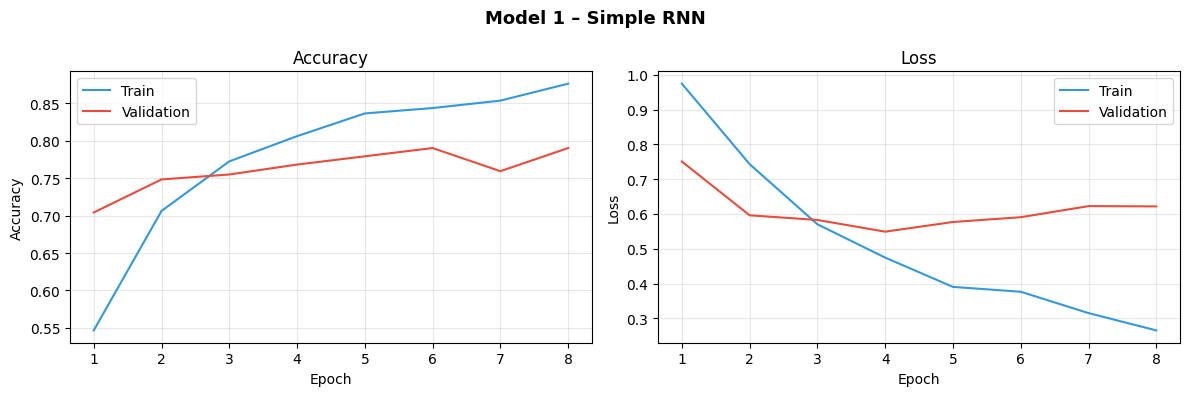

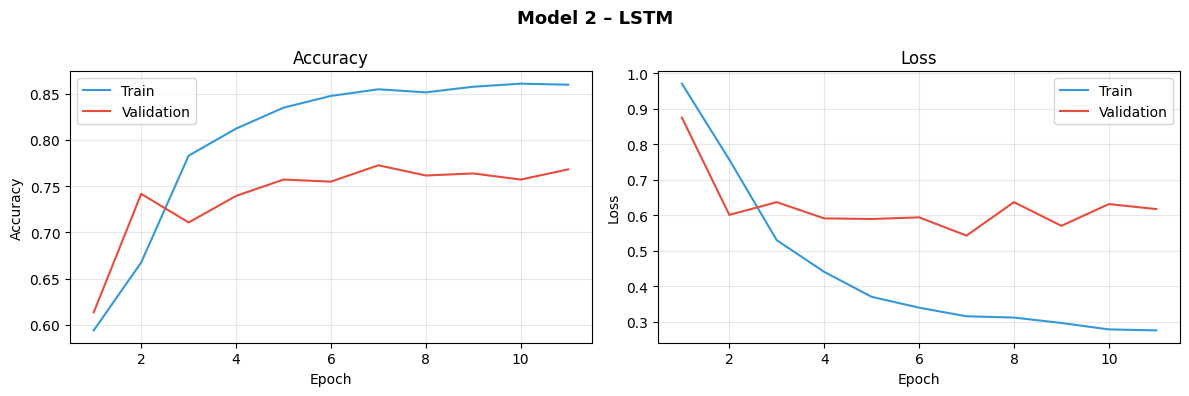

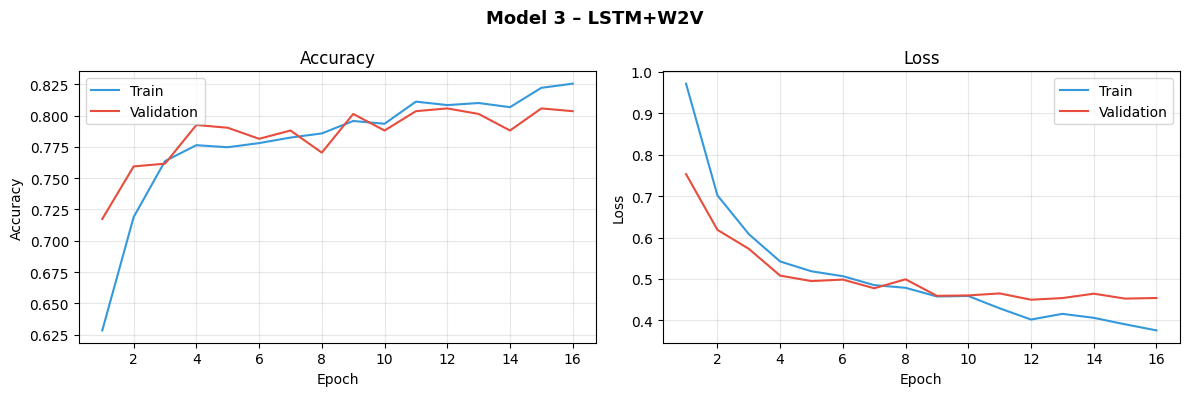

In [ ]:
def plot_history(history, title, color):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ep = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(ep, history.history['accuracy'],     color='#3498db', label='Train')
    axes[0].plot(ep, history.history['val_accuracy'], color='#e74c3c',  label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(ep, history.history['loss'],     color='#3498db', label='Train')
    axes[1].plot(ep, history.history['val_loss'], color='#e74c3c', label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_history(hist1, 'Model 1 – Simple RNN', '#e74c3c')
plot_history(hist2, 'Model 2 – LSTM',       '#3498db')
plot_history(hist3, 'Model 3 – LSTM+W2V',  '#2ecc71')

### Evaluate Models – Accuracy, Confusion Matrix, Classification Report


  Model1 SimpleRNN
  Accuracy: 76.82%  |  Loss: 0.5491
              precision    recall  f1-score   support

    Negative       0.50      0.02      0.03        61
     Neutral       0.92      0.91      0.91       278
    Positive       0.53      0.83      0.65       114

    accuracy                           0.77       453
   macro avg       0.65      0.59      0.53       453
weighted avg       0.77      0.77      0.73       453



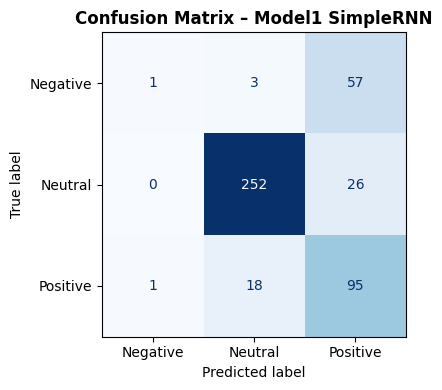


  Model2 LSTM
  Accuracy: 77.26%  |  Loss: 0.5426
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        61
     Neutral       0.92      0.91      0.92       278
    Positive       0.54      0.85      0.66       114

    accuracy                           0.77       453
   macro avg       0.49      0.59      0.53       453
weighted avg       0.70      0.77      0.73       453



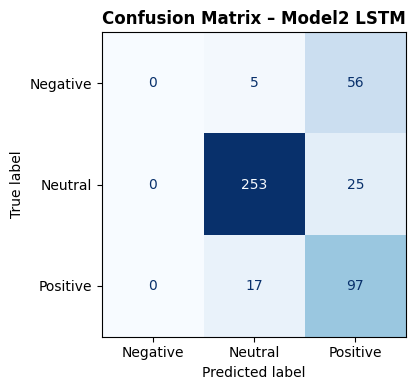


  Model3 LSTM+W2V
  Accuracy: 80.57%  |  Loss: 0.4499
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        61
     Neutral       0.94      0.95      0.95       278
    Positive       0.58      0.88      0.70       114

    accuracy                           0.81       453
   macro avg       0.51      0.61      0.55       453
weighted avg       0.72      0.81      0.76       453



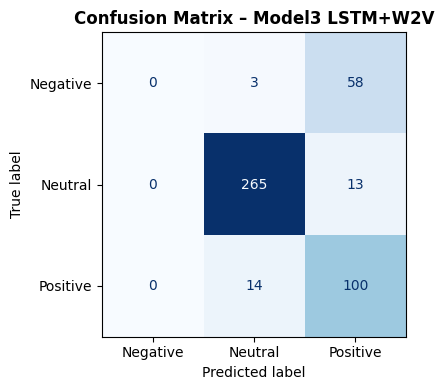

In [ ]:
def evaluate(model, name, X_pad, y_cat):
    y_true = np.argmax(y_cat, axis=1)
    y_pred = np.argmax(model.predict(X_pad, verbose=0), axis=1)
    loss, acc = model.evaluate(X_pad, y_cat, verbose=0)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'  Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix – {name}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{name}_cm.png', dpi=120); plt.show()
    return acc, loss, y_pred

acc1, loss1, pred1 = evaluate(model1, 'Model1 SimpleRNN',  X_test_pad, y_test)
acc2, loss2, pred2 = evaluate(model2, 'Model2 LSTM',        X_test_pad, y_test)
acc3, loss3, pred3 = evaluate(model3, 'Model3 LSTM+W2V',    X_test_pad, y_test)

### Model 1 vs Model 2 vs Model 3 – Comparison

           Model     Embedding Accuracy   Loss Train Time
Model1 SimpleRNN Trainable 64d   76.82% 0.5491         8s
     Model2 LSTM Trainable 64d   77.26% 0.5426        22s
 Model3 LSTM+W2V Word2Vec 300d   80.57% 0.4499        53s


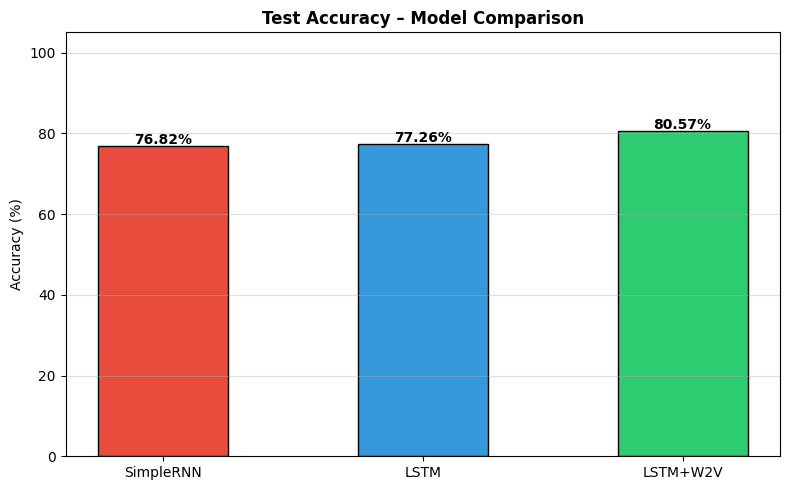

In [ ]:
# Summary table
cmp = pd.DataFrame({
    'Model'     : ['Model1 SimpleRNN', 'Model2 LSTM', 'Model3 LSTM+W2V'],
    'Embedding' : ['Trainable 64d', 'Trainable 64d', 'Word2Vec 300d'],
    'Accuracy'  : [f'{acc1*100:.2f}%', f'{acc2*100:.2f}%', f'{acc3*100:.2f}%'],
    'Loss'      : [f'{loss1:.4f}', f'{loss2:.4f}', f'{loss3:.4f}'],
    'Train Time': [f'{time1:.0f}s', f'{time2:.0f}s', f'{time3:.0f}s']
})
print(cmp.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(['SimpleRNN', 'LSTM', 'LSTM+W2V'],
               [acc1*100, acc2*100, acc3*100],
               color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, [acc1, acc2, acc3]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')
plt.ylim(0, 105)
plt.title('Test Accuracy – Model Comparison', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('comparison.png', dpi=120); plt.show()

---
## Task 4.5.4 – Error Analysis

In [ ]:
# Misclassified examples from best model (Model 3)
y_true = np.argmax(y_test, axis=1)

errors = []
for i, (t, p) in enumerate(zip(y_true, pred3)):
    if t != p:
        errors.append({'Text': X_test[i][:100],
                       'True': CLASS_NAMES[t],
                       'Predicted': CLASS_NAMES[p]})

print(f'Total errors: {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)')
print('\n--- 3 Sample Misclassifications ---')
for k, e in enumerate(errors[:3], 1):
    print(f'\n{k}. Text      : {e["Text"]}')
    print(f'   True      : {e["True"]}')
    print(f'   Predicted : {e["Predicted"]}')

Total errors: 88 / 453 (19.4%)

--- 3 Sample Misclassifications ---

1. Text      : september alone market declined percent year year million liter
   True      : Negative
   Predicted : Positive

2. Text      : raute reported loss per share eur first half eps eur corresponding period
   True      : Negative
   Predicted : Positive

3. Text      : finnish electronics contract manufacturer scanfil report net sale eur mn second quarter eur mn year 
   True      : Negative
   Predicted : Positive


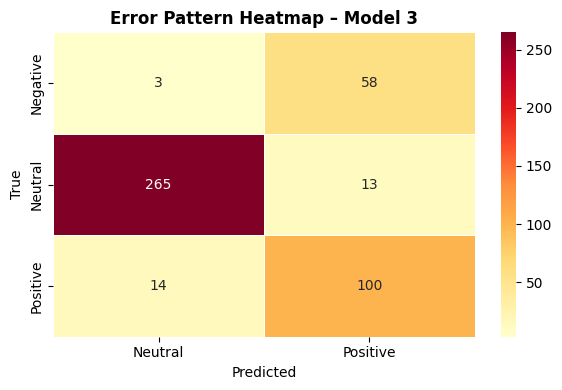

In [ ]:
# Error pattern heatmap
ct = pd.crosstab(
    pd.Series([CLASS_NAMES[i] for i in y_true],  name='True'),
    pd.Series([CLASS_NAMES[i] for i in pred3], name='Predicted')
)
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Error Pattern Heatmap – Model 3', fontweight='bold')
plt.tight_layout(); plt.savefig('error_heatmap.png', dpi=120); plt.show()



---
## Task 4.5.5 – GUI for Real-Time Prediction (Gradio)

In [ ]:
import gradio as gr

def predict(text):
    if not text.strip():
        return 'Please enter a sentence.', ''
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = model3.predict(padded, verbose=0)[0]
    pred    = CLASS_NAMES[np.argmax(probs)]
    result  = f"Sentiment: {pred}  |  Confidence: {max(probs)*100:.1f}%"
    probs_text = (
        f"Negative : {probs[0]*100:.1f}%\n"
        f"Neutral  : {probs[1]*100:.1f}%\n"
        f"Positive : {probs[2]*100:.1f}%"
    )
    return result, probs_text


In [2]:
import gradio as gr

gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=3, placeholder='Enter financial text here...', label='Input Text'),
    outputs=[
        gr.Textbox(label='Prediction'),
        gr.Textbox(label='Class Probabilities')
    ],
    title='Financial Sentiment Prediction',
    description='RNN/LSTM based sentiment classifier for financial text.',
    examples=[
        ['Net profit increased by 22% compared to last year.'],
        ['Operating losses widened due to rising material costs.'],
        ['The board approved the annual financial report.']
    ]
).launch(share=True, debug=True)

NameError: name 'predict' is not defined